In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("borapajo/food-choices")

print("Path to dataset files:", path)

In [ ]:
cd /root/.cache/kagglehub/datasets/borapajo/food-choices/versions/5

/root/.cache/kagglehub/datasets/borapajo/food-choices/versions/5


In [ ]:
df = pd.read_csv('food_coded.csv')

## Inspection

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-null    float64
 13  diet_

Notes:
- Gender is numerical (1 = Female, 2 = Male)

In [ ]:
df.head()

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,cook,comfort_food_reasons_coded.1,cuisine,diet_current,diet_current_coded,drink,eating_changes,eating_changes_coded,eating_changes_coded1,eating_out,employment,ethnic_food,exercise,father_education,father_profession,fav_cuisine,fav_cuisine_coded,fav_food,food_childhood,fries,fruit_day,grade_level,greek_food,healthy_feeling,healthy_meal,ideal_diet,ideal_diet_coded,income,indian_food,italian_food,life_rewarding,marital_status,meals_dinner_friend,mother_education,mother_profession,nutritional_check,on_off_campus,parents_cook,pay_meal_out,persian_food,self_perception_weight,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,2.0,9,NaN,eat good and exercise,1,1.0,eat faster,1,1,3,3.0,1,1.0,5.0,profesor,Arabic cuisine,3,1.0,rice and chicken,2,5,2,5,2,looks not oily,being healthy,8,5.0,5,5,1.0,1.0,"rice, chicken, soup",1.0,unemployed,5,1.0,1,2,5.0,3.0,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,3.0,1,1.0,I eat about three times a day with some snacks...,2,2.0,I eat out more than usual.,1,2,2,2.0,4,1.0,2.0,Self employed,Italian,1,1.0,"chicken and biscuits, beef soup, baked beans",1,4,4,4,5,"Grains, Veggies, (more of grains and veggies),...",Try to eat 5-6 small meals a day. While trying...,3,4.0,4,4,1.0,2.0,"Pasta, steak, chicken",4.0,Nurse RN,4,1.0,1,4,4.0,3.0,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,1.0,1,3.0,"toast and fruit for breakfast, salad for lunch...",3,1.0,sometimes choosing to eat fast food instead of...,1,3,2,3.0,5,2.0,2.0,owns business,italian,1,3.0,"mac and cheese, pizza, tacos",1,5,3,5,6,usually includes natural ingredients; nonproce...,i would say my ideal diet is my current diet,6,6.0,5,5,7.0,2.0,"chicken and rice with veggies, pasta, some kin...",2.0,owns business,4,2.0,1,3,5.0,6.0,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,2.0,2,2.0,"College diet, cheap and easy foods most nights...",2,2.0,Accepting cheap and premade/store bought foods,1,3,2,3.0,5,3.0,2.0,Mechanic,Turkish,3,1.0,"Beef stroganoff, tacos, pizza",2,4,4,5,7,"Fresh fruits& vegetables, organic meats","Healthy, fresh veggies/fruits & organic foods",2,6.0,5,5,2.0,2.0,Grilled chicken \rStuffed Shells\rHomemade Chili,4.0,Special Education Teacher,2,1.0,1,2,5.0,5.0,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,1.0,1,2.0,I try to eat healthy but often struggle becaus...,2,2.0,I have eaten generally the same foods but I do...,3,4,2,2.0,4,1.0,4.0,IT,Italian,1,3.0,"Pasta, chicken tender, pizza",1,4,4,4,6,"A lean protein such as grilled chicken, green ...",Ideally I would like to be able to eat healthi...,2,6.0,2,5,1.0,1.0,"Chicken Parmesan, Pulled Pork, Spaghetti and m...",5.0,Substance Abuse Conselor,3,1.0,1,4,2.0,4.0,1.0,1.0,4,940.0,500,Softball,4,2,760,190


Dropping of Unnecessary Columns basing on the Readed Data Base via using Panda

In [ ]:
drop_cols = ['comfort_food_reasons', 'comfort_food_reasons_coded.1', 'eating_changes_coded1', 'fav_cuisine']
df = df.drop(columns=drop_cols)

GPA and weight


In [ ]:
df['GPA'] = pd.to_numeric(df['GPA'], errors='coerce')
df['weight'] = pd.to_numeric(df['weight'], errors='coerce')

Look at the distributions. Seeing as they are both skewed, we impute with the median.

Impute all interval vars with median

ordinals

In [ ]:
# things with rank.
ordinals = ['calories_day', 'cook', 'exercise', 'fries', 'fruit_day', 'grade_level', 'greek_food','on_off_campus', 'parents_cook', 'healthy_feeling', 'indian_food', 'italian_food', 'life_rewarding', 'mother_education', 'persian_food', 'self_perception_weight', 'thai_food']

In [ ]:
# special impute

# father_education: median per father_profession
df['father_education'] = df.groupby('father_profession')['father_education'].transform(
    lambda x: x.fillna(x.median())
)
df['father_education'] = df['father_education'].fillna(df['father_education'].median())

# income: median per (father_profession, mother_profession)
df['income'] = df.groupby(['father_profession', 'mother_profession'])['income'].transform(
    lambda x: x.fillna(x.median())
)
df['income'] = df['income'].fillna(df['income'].median())

In [ ]:
df[ordinals] = df[ordinals].fillna(df[ordinals].mode())

cats

In [ ]:
categoricals = ['type_sports', 'Gender', 'breakfast', 'coffee', 'comfort_food_reasons_coded', 'diet_current_coded', 'eating_changes_coded', 'father_profession', 'fav_cuisine_coded', 'ideal_diet_coded', 'mother_profession', ]

In [ ]:
cols_to_drop = [col for col in categoricals if df[col].nunique() > 50]
df = df.drop(columns=cols_to_drop)

categoricals = [col for col in categoricals if col not in cols_to_drop]

# avoid curse of dimensionality, way too many unique values. i set it to 50 here

In [ ]:
df = pd.get_dummies(df, columns=categoricals)

text

In [ ]:
text_cols = ['comfort_food', 'diet_current', 'eating_changes', 'food_childhood', 'healthy_meal', 'ideal_diet', 'meals_dinner_friend']
df = df.drop(columns=text_cols)

# the text in this ds is basicallyt useless unless we embed into some sort of high level dimension

In [ ]:
df = df.astype(np.float64)

# rest of imputation

- Getting the GPA
- Getting The Weight


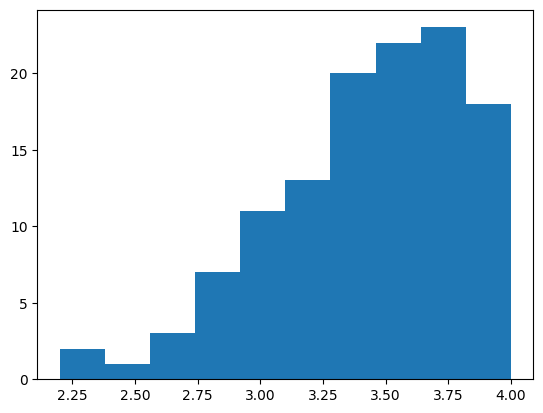

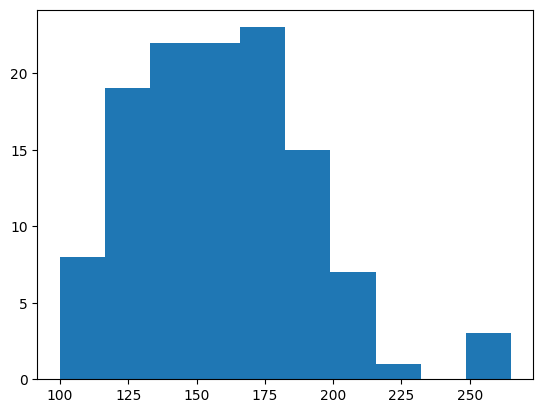

In [ ]:
plt.hist(df['GPA'])
plt.show()

plt.hist(df['weight'])
plt.show()

In [ ]:
gpa_median = df['GPA'].median()
weight_median = df['weight'].median()

df['GPA'] = df['GPA'].fillna(gpa_median)
df['weight'] = df['weight'].fillna(weight_median)

In [ ]:
median_cols = ['GPA', 'weight', 'calories_scone', 'tortilla_calories', 'turkey_calories', 'waffle_calories', 'calories_day']
df[median_cols] = df[median_cols].fillna(df[median_cols].median())

In [ ]:
mode_cols = ['cook',
 'cuisine',
 'drink',
 'employment',
 'exercise',
 'fav_food',
 'life_rewarding',
 'marital_status',
 'mother_education',
 'on_off_campus',
 'persian_food',
 'self_perception_weight',
 'soup',
 'sports']
df[mode_cols] = df[mode_cols].fillna(df[mode_cols].mode().iloc[0])

### Normalization

In [ ]:
normalize_cols = ['GPA', 'weight', 'calories_chicken', 'calories_scone', 'turkey_calories', 'tortilla_calories', 'turkey_calories', 'waffle_calories']

In [ ]:
scaler = StandardScaler()
df[normalize_cols] = scaler.fit_transform(df[normalize_cols])

### Extraction

In [ ]:
df.to_csv('preprocessed_food.csv')